# Across-problem analysis (from scratch)
This notebook loads `subjects_trials_by_problem` and produces requested across-problem plots.


In [ ]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Make project imports work (assumes notebook is in repo or run from a place where ../src exists)
sys.path.insert(0, str(Path.cwd().parent))

from src.behavior_import.import_data import *
from src.behavior_import.extract_trials import *
from src.behavior_analysis.get_total_reversals import *
from src.behavior_analysis.get_good_reversal_info import *
from scripts.to_sort.fix_grid_maze_cohort_02_problems import *

import src.behavior_visualization.plot_style  # noqa: F401 — applies rcParams
from src.behavior_visualization.plot_style import MOUSE_COLORS

In [4]:
# --- USER CELL (as requested) ---
task = "grid-maze"

folder_name = None
cohort = None
if task == "grid-maze":
    cohort = "cohort-02"
    folder_name = "3x3_maze_blocked_reward_bandit"
elif task == "open-field":
    cohort = "cohort-01"
    folder_name = "3x3_field_blocked_reward_bandit"
root = f"/Volumes/behrens/meg/{folder_name}/{cohort}/rawdata/"

subjects_data = import_data(root)
subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)
if task == "grid-maze" and cohort == "cohort-02":
    subjects_trials_by_problem = fix_grid_maze_cohort_02_problems(subjects_trials_by_problem)

# quick peek
list(subjects_trials_by_problem.keys())[:10], len(subjects_trials_by_problem)


[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-27_date-20260124/behav/._MY_04_R-2026-01-24-124422.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-55_date-20260209/behav/._MY_04_R-2026-02-09-103918.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-28_date-20260124/behav/._MY_04_R-2026-01-24-165301.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volumes/behrens/meg/3x3_maze_blocked_reward_bandit/cohort-02/rawdata/sub-03_id-MY_04_R/ses-12_date-20260116/behav/._MY_04_R-2026-01-16-143640.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte.
[WARN] Failed to read /Volum

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 11)

In [5]:
# Change this as needed
cutoff_problem = 7


In [ ]:
from src.behavior_analysis.problem_utils import (
    problem_to_int,
    session_sort_key,
    flatten_trials,
    get_session_map,
    summarize_by_problem,
    flatten_trials_by_session,
    mean_block_length_from_indices,
)
from src.behavior_visualization.plot_problem_summary import plot_metric_by_problem

## 1) Number of sessions per problem (mean ± SE across mice + per-mouse lines)


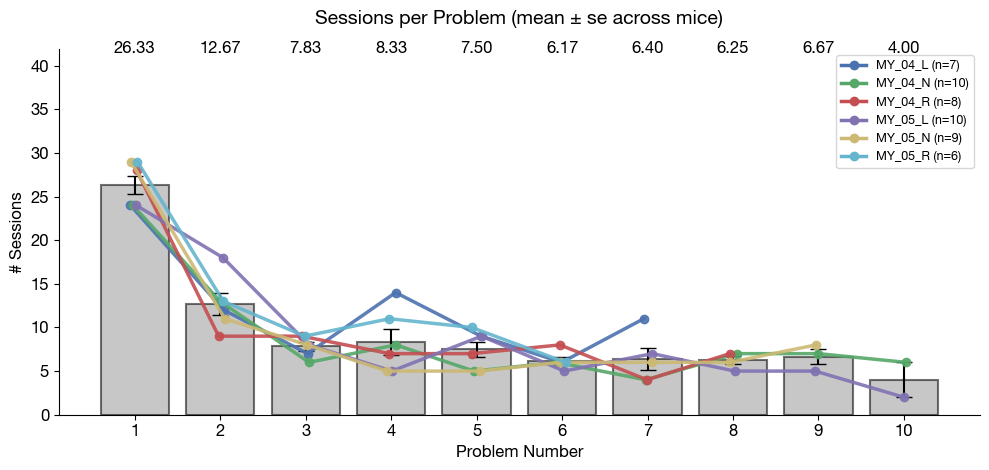

In [7]:
# Build per-mouse: problem -> n_sessions
per_mouse_sessions = {}

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None:
        continue
    for mouse, subj_trials in subj_map.items():
        sess_map = get_session_map(subj_trials)
        n_sessions = len(sess_map)
        per_mouse_sessions.setdefault(mouse, {})[p] = float(n_sessions)

# Ignore the last problem (largest p) for each mouse
for mouse, pmap in per_mouse_sessions.items():
    if not pmap:
        continue
    last_p = max(pmap.keys())
    pmap.pop(last_p, None)

summary_sessions = summarize_by_problem(per_mouse_sessions)

plot_metric_by_problem(
    summary_sessions,
    title="Sessions per Problem (mean ± se across mice)",
    ylabel="# Sessions",
    jitter=0.06
)

## 2) Number of reversals per problem
For problems < cutoff: **good reversals**. For problems ≥ cutoff: **total (good+bad)**.


[SKIP] MY_05_L boundary@401 (good_reversals, block 8): more than 1 zero rewards in [4, 0, 0]
[SKIP] MY_04_N boundary@186 (good_reversals, block 7): more than 1 zero rewards in [4, 0, 0]
[SKIP] MY_04_L boundary@103 (good_reversals, block 3): more than 1 zero rewards in [0, 0, 4]
[SKIP] MY_05_L boundary@146 (good_reversals, block 4): more than 1 zero rewards in [4, 0, 0]


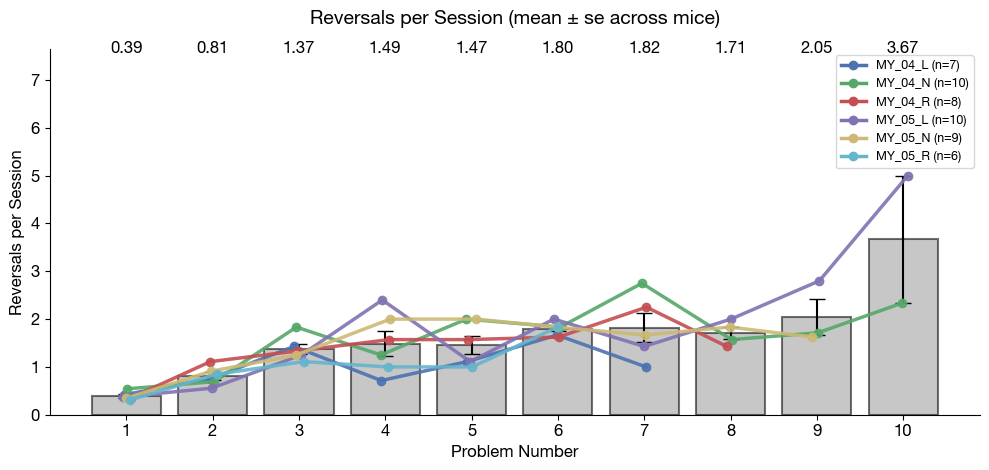

In [8]:
per_mouse_reversals = {}

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None:
        continue

    rw = get_good_reversal_info(subj_map, include_first_block=False)

    # Normalize rw to dict[mouse] -> {"good": [...], "bad": [...]}
    rw_norm = {}
    for mouse, v in rw.items():
        if isinstance(v, dict) and ("good" in v or "bad" in v):
            rw_norm[mouse] = {"good": list(v.get("good", [])), "bad": list(v.get("bad", []))}
        elif isinstance(v, list):
            rw_norm[mouse] = {"good": v, "bad": []}
        else:
            rw_norm[mouse] = {"good": [], "bad": []}

    rw = rw_norm

    for mouse, subj_trials in subj_map.items():

        g = len(rw.get(mouse, {}).get("good", []))
        b = len(rw.get(mouse, {}).get("bad", []))

        total_rev = g if p < cutoff_problem else (g + b)

        sess_map = get_session_map(subj_trials)
        n_sessions = len(sess_map)

        if n_sessions == 0:
            continue

        val = total_rev / n_sessions

        per_mouse_reversals.setdefault(mouse, {})[p] = float(val)


# ---- EXCLUDE LAST PROBLEM PER MOUSE ----
for mouse, pmap in per_mouse_reversals.items():
    if not pmap:
        continue
    last_p = max(pmap.keys())
    pmap.pop(last_p, None)


summary_reversals = summarize_by_problem(per_mouse_reversals)

plot_metric_by_problem(
    summary_reversals,
    title=f"Reversals per Session (mean ± se across mice)",
    ylabel="Reversals per Session",
    jitter=0.06
)

## 3) Mean block length per problem
For problems < cutoff: boundary = **good**. For problems ≥ cutoff: boundary = **all**.

Block length is computed from reversal indices as differences between consecutive boundaries (including start at 0), then averaged within each mouse for that problem.


In [ ]:
# mean_block_length_from_indices and flatten_trials_by_session imported above from src.

import numpy as np
from collections import Counter

per_mouse_blocklen = {}

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None:
        continue

    rw = get_good_reversal_info(subj_map, include_first_block=False)

    # Normalize rw to dict[mouse] -> {"good": [...], "bad": [...]}
    rw_norm = {}
    for mouse, v in rw.items():
        if isinstance(v, dict) and ("good" in v or "bad" in v):
            rw_norm[mouse] = {"good": list(v.get("good", [])), "bad": list(v.get("bad", []))}
        elif isinstance(v, list):
            rw_norm[mouse] = {"good": list(v), "bad": []}
        else:
            rw_norm[mouse] = {"good": [], "bad": []}
    rw = rw_norm

    for mouse, trials_by_session in subj_map.items():
        trials_flat = flatten_trials_by_session(trials_by_session)
        T = len(trials_flat)
        if T == 0:
            continue

        if p < cutoff_problem:
            rev_events = rw.get(mouse, {}).get("good", [])
        else:
            rev_events = rw.get(mouse, {}).get("good", []) + rw.get(mouse, {}).get("bad", [])

        # rev_events are dicts like {"reversal_idx": ...}
        idxs = []
        for r in rev_events:
            if isinstance(r, dict) and "reversal_idx" in r:
                idxs.append(r["reversal_idx"])
            elif isinstance(r, (int, float, np.integer)):
                idxs.append(int(r))

        per_mouse_blocklen.setdefault(mouse, {})[p] = float(mean_block_length_from_indices(idxs, T))

# Exclude last problem per mouse
for mouse, pmap in per_mouse_blocklen.items():
    if pmap:
        pmap.pop(max(pmap.keys()), None)

# how many mice have a finite value at each problem?
finite_counts = Counter()
for mouse, pmap in per_mouse_blocklen.items():
    for p, v in pmap.items():
        if np.isfinite(v):
            finite_counts[p] += 1

print("finite counts per problem:", dict(sorted(finite_counts.items())))
print("problems present in per_mouse_blocklen:", sorted({p for pm in per_mouse_blocklen.values() for p in pm}))

summary_blocklen = summarize_by_problem(per_mouse_blocklen)

plot_metric_by_problem(
    summary_blocklen,
    title=f"Mean block length per problem (good if < {cutoff_problem}, all if ≥ {cutoff_problem}) [last problem excluded]",
    ylabel="Mean block length (trials)",
    jitter=0.06
)

## 4) Distribution of trials per session (all mice), only for problems ≥ cutoff


In [ ]:
import re
from datetime import datetime

from src.behavior_analysis.problem_utils import (
    n_trials_in_session,
    total_trials_in_problem,
    mean_block_length_from_indices,
    reversals_from_blocks_counter,
    summarize_by_problem_safe,
    exclude_last_problem_per_mouse,
)


def sort_session_id(session_id: str):
    """Sort key: ses-XX number, then date-YYYYMMDD, then session_id string."""
    m_ses = re.search(r"ses-(\d+)", session_id)
    m_date = re.search(r"date-(\d{8})", session_id)
    ses_num = int(m_ses.group(1)) if m_ses else float("inf")
    dt = datetime.strptime(m_date.group(1), "%Y%m%d") if m_date else datetime.max
    return (ses_num, dt, session_id)

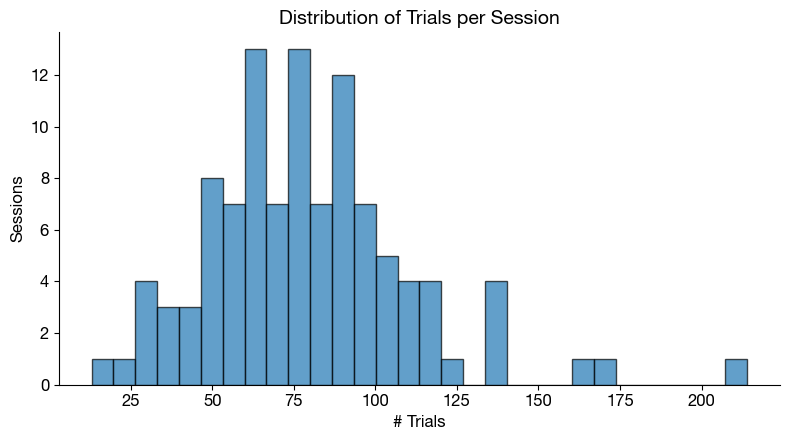

Sessions counted: 107
Median trials/session: 76.0 | Mean: 79.20560747663552
Unique trial counts (first 25): [13. 21. 29. 32. 33. 37. 39. 42. 43. 46. 47. 49. 51. 52. 53. 54. 55. 56.
 58. 60. 61. 62. 63. 64. 65.]


In [10]:
trial_counts = []

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None or p < cutoff_problem:
        continue

    # subj_map: dict[mouse -> dict[session_id -> session_data]]
    for mouse, sessions in subj_map.items():
        if not isinstance(sessions, dict):
            continue

        for session_id, sess in sessions.items():
            nT = n_trials_in_session(sess)
            if nT > 0:
                trial_counts.append(nT)

trial_counts = np.asarray(trial_counts, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(trial_counts[np.isfinite(trial_counts)], bins=30, edgecolor="black", alpha=0.7)
ax.set_title(f"Distribution of Trials per Session")
ax.set_xlabel("# Trials")
ax.set_ylabel("Sessions")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig)
fig.savefig("trials_per_session_histogram.png", dpi=300)

print("Sessions counted:", int(np.isfinite(trial_counts).sum()))
print("Median trials/session:", float(np.nanmedian(trial_counts)), "| Mean:", float(np.nanmean(trial_counts)))
print("Unique trial counts (first 25):", np.unique(trial_counts)[:25])

## 5) Distribution of total reversals per session (all mice), only for problems ≥ cutoff


In [ ]:
# reversals_from_blocks_counter imported above from src.behavior_analysis.problem_utils

import numpy as np
import matplotlib.pyplot as plt

rev_counts = []

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None or p < cutoff_problem:
        continue

    # subj_map[mouse] is dict[session_id -> session_data]
    for mouse, sessions in subj_map.items():
        if not isinstance(sessions, dict):
            continue
        for sess_id, session_data in sessions.items():
            rev_counts.append(reversals_from_blocks_counter(session_data))

rev_counts = np.asarray(rev_counts, dtype=float)
vals = rev_counts[np.isfinite(rev_counts)]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(vals, bins=30, edgecolor="black", alpha=0.7)
ax.set_title(f"Distribution of total reversals per session (max(blocks)-1), problems ≥ {cutoff_problem}")
ax.set_xlabel("# reversals in session (max blocks - 1)")
ax.set_ylabel("Count (sessions)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
plt.close(fig)

print("Sessions counted:", int(vals.size))
print("Median reversals/session:", float(np.nanmedian(vals)) if vals.size else np.nan,
      "| Mean:", float(np.nanmean(vals)) if vals.size else np.nan)

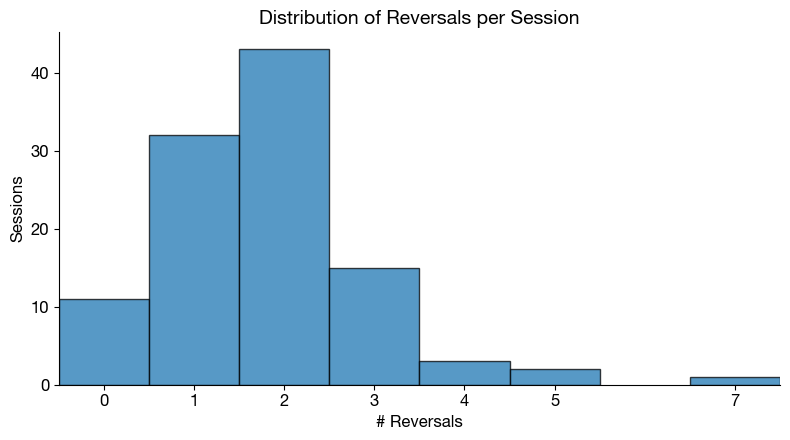

Sessions counted: 107
Median: 2.0 | Mean: 1.794392523364486


In [12]:
import numpy as np
import matplotlib.pyplot as plt

vals = rev_counts[np.isfinite(rev_counts)].astype(int)

if vals.size == 0:
    print("No sessions found.")
else:
    uniq, counts = np.unique(vals, return_counts=True)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.bar(
        uniq,
        counts,
        width=1.0,            # full integer width → no gaps
        align="center",
        edgecolor="black",
        linewidth=1.0,
        alpha=0.75
    )

    ax.set_title(
        f"Distribution of Reversals per Session"
    )
    ax.set_xlabel("# Reversals")
    ax.set_ylabel("Sessions")

    ax.set_xticks(uniq)
    ax.set_xlim(uniq.min() - 0.5, uniq.max() + 0.5)
    ax.margins(x=0)          # remove extra padding

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    fig.savefig("reversals_per_session_histogram.png", dpi=300)

    print("Sessions counted:", int(vals.size))
    print("Median:", float(np.median(vals)), "| Mean:", float(np.mean(vals)))

## 6) Distribution of # sessions per problem across mice, only for problems ≥ cutoff
This treats each (mouse, problem) as one datapoint: how many sessions did that mouse contribute to that problem?


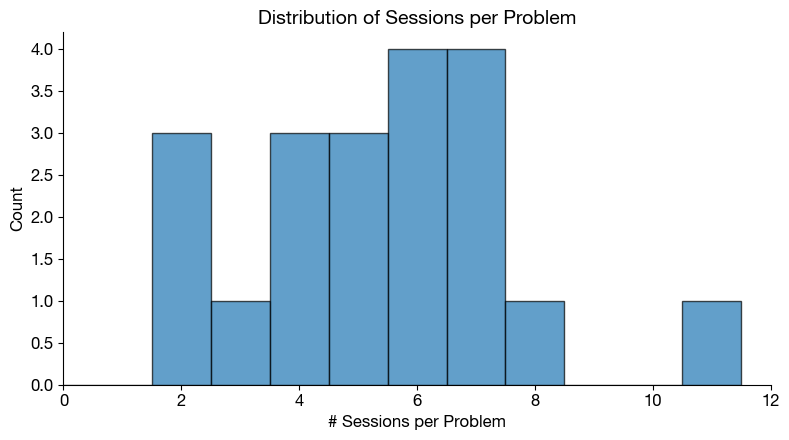

,mouse,problem,n_sessions
0,MY_04_R,7,4
1,MY_05_R,7,4
2,MY_04_N,7,4
3,MY_04_L,7,11
4,MY_05_L,7,7


Mouse×problem datapoints: 20 | Mice: 6 | Problems: 5
Median sessions/problem: 5.5 | Mean: 5.35


In [13]:
vals = []
rows = []

for prob_key, subj_map in subjects_trials_by_problem.items():
    p = problem_to_int(prob_key)
    if p is None or p < cutoff_problem:
        continue
    for mouse, subj_trials in subj_map.items():
        n_sessions = len(get_session_map(subj_trials))
        vals.append(n_sessions)
        rows.append({"mouse": mouse, "problem": p, "n_sessions": n_sessions})

df_sessions_dist = pd.DataFrame(rows)
vals = np.asarray(vals, dtype=float)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(vals[np.isfinite(vals)], bins=np.arange(0, np.nanmax(vals)+2) - 0.5 if vals.size else 10, edgecolor="black", alpha=0.7)
ax.set_title(f"Distribution of Sessions per Problem")
ax.set_xlabel("# Sessions per Problem")
ax.set_ylabel("Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0,12)
plt.tight_layout()
plt.show()
fig.savefig("sessions_per_problem_histogram.png", dpi=300)
plt.close(fig)

display(df_sessions_dist.head())
print("Mouse×problem datapoints:", len(df_sessions_dist), "| Mice:", df_sessions_dist["mouse"].nunique(), "| Problems:", df_sessions_dist["problem"].nunique())
print("Median sessions/problem:", float(np.nanmedian(vals)), "| Mean:", float(np.nanmean(vals)))
